# MxN multi-widget editor: layout as code

The MxN multi-widget editor lets you build arbitrary grids of synchronised
render windows. This notebook walks through a multimodal storyline (CT next
to MR), and along the way demonstrates the GET-modify-PUT pattern for
*layout-as-code*: the same Python DSL builds layouts from scratch, parses
the workbench's live layout, and validates documents before they cross the
network.

You will learn how to:

- Open the MxN editor and inspect its current layout
- Build a typed `MxNLayoutDocument` and apply it via `set_layout`
- Use semantic window ids that encode modality and anatomical plane
- Drive per-cell node visibility so each cell shows only what it should
- Move the crosshair and observe synchronised updates across cells

**Prerequisites**

- A running MITK Workbench at `http://localhost:8080`.
- The **MxN multi-widget editor** must be open in the workbench before
  you run the notebook. Open it via *Window > New Editor > MxN*
  (or switch to a perspective that includes it). `wb.show()` does
  not open MxN -- the StdMultiWidget gets shown instead.
- The optional `mitk` Python package (provides `mitk.mxn.layout`). This
  package ships with a local MITK build's Python wrapping; it is not
  available from public PyPI. Without it, the typed DSL paths
  (`get_layout`, `set_layout(doc)`, `update_layout`, ...) raise
  `ImportError`. The raw-dict path (`get_layout_json`,
  `set_layout(dict)`) is always available -- see the callout near the
  end of this notebook.
- Install the library with the layout extra:
  `pip install -e ".[layout]"` from the repo root.


## 1. Connect and import the DSL

The DSL is gated on the optional `mitk` package. We fail loudly with an
actionable message if it is missing -- the raw-dict path remains usable
without it, but every cell below uses the typed builders.


In [1]:
import mitk_workbench_remote as mw
from mitk_workbench_remote.examples import phantoms

wb = mw.connect("http://localhost:8080")
if not wb.ping():
    raise SystemExit("Workbench unreachable at http://localhost:8080. Start it and re-run.")

try:
    from mitk.mxn.layout import (
        LayoutWindow,
        MxNLayoutDocument,
        Split,
        ViewDirection,
    )
except ImportError as exc:
    raise SystemExit(
        "This notebook requires the optional 'mitk' package. "
        "Build it from a local MITK CMake build (Wrapping/Python) and install the wheel."
    ) from exc

print(f"Connected to {wb.info.name}; mitk.mxn.layout DSL loaded.")

if not wb.mxn.get_info().active:
    raise SystemExit(
        "The MxN multi-widget editor is not open in the workbench. "
        "Open it via 'Window > New Editor > MxN' and re-run."
    )


Connected to MITK Workbench REST API; mitk.mxn.layout DSL loaded.


## 2. Two modalities -- one body, two textures

We use a deliberately simplified phantom: the body and a small offset
tumor. The shape primitives differ by modality so the two volumes are
visually distinct -- spheres for MR, cubes for CT -- but they share the
same geometry so they overlay cleanly.


In [2]:
mr_image = phantoms.make_body_with_tumor("mr")
ct_image = phantoms.make_body_with_tumor("ct")

mr_node = wb.show(mr_image, name="MR", color=(0.95, 0.30, 0.30))
ct_node = wb.show(ct_image, name="CT", color=(0.30, 0.55, 0.95))
print(f"Loaded {mr_node} and {ct_node}.")


Loaded <DataNode 'MR' (Image) @ /MR uid=node_3> and <DataNode 'CT' (Image) @ /CT uid=node_4>.


## 3. Open the MxN editor with the default layout

`wb.mxn` returns a stateless handle to the MxN editor. Out of the box the
editor opens with a single cell, so both modalities currently render in the
same window. To see them overlaid, we put MR on top and dial its opacity
down to 0.5.


In [3]:
mxn = wb.mxn
info = mxn.get_info()
print(f"alias={info.alias}  active={info.active}  cells={info.windows}")

# Stack MR above CT and make MR semi-transparent so both modalities are visible.
for cell in mxn.list_windows():
    cell.set_node_layer(ct_node, 0)
    cell.set_node_layer(mr_node, 1)
mr_node.opacity = 0.5
wb.update()
print("MR is on top at 50% opacity.")


alias=mxn  active=True  cells=('mxn__ct_axial', 'mxn__ct_coronal', 'mxn__ct_sagittal', 'mxn__mr_axial', 'mxn__mr_coronal', 'mxn__mr_sagittal')
MR is on top at 50% opacity.


**Try this:** open the workbench's data inspector for the active cell.
Both `MR` and `CT` are listed -- in this default single-cell layout, every
visible node renders in every window.


## 4. Layout as code: GET the current document

`mxn.get_layout()` parses the live workbench layout into a typed
`MxNLayoutDocument`. Repr is human-readable; `to_json()` shows the wire
form.


In [4]:
current = mxn.get_layout()
print(current)

MxNLayoutDocument(name='modality grid', version='2.0', windows=6, groups=2)


Layouts also support pretty html print/representation.

In [5]:
current

CT axialmxn__ct_axialview: axialselection: ct,CT coronalmxn__ct_coronalview: coronalselection: ct,CT sagittalmxn__ct_sagittalview: sagittalselection: ct
MR axialmxn__mr_axialview: axialselection: mr,MR coronalmxn__mr_coronalview: coronalselection: mr,MR sagittalmxn__mr_sagittalview: sagittalselection: mr


### Build a one-row, three-plane layout

A common quick-look layout is a single row of three cells, one per
anatomical plane, all linked to the same selection group. We construct
the windows manually so the cell ids encode the plane (`mxn__row_axial`
etc.) -- semantic ids make the next steps easier to read.


In [6]:
row_doc = MxNLayoutDocument.create(
    root=Split.horizontal(
        LayoutWindow.create(
            id="mxn__row_axial",
            view_direction=ViewDirection.AXIAL,
            selection="main",
            name="Axial",
        ),
        LayoutWindow.create(
            id="mxn__row_coronal",
            view_direction=ViewDirection.CORONAL,
            selection="main",
            name="Coronal",
        ),
        LayoutWindow.create(
            id="mxn__row_sagittal",
            view_direction=ViewDirection.SAGITTAL,
            selection="main",
            name="Sagittal",
        ),
    ),
    name="multimodal row",
)
mxn.set_layout(row_doc)
print(f"Cells now: {[c.id for c in mxn.list_windows()]}")
row_doc

Cells now: ['mxn__row_axial', 'mxn__row_coronal', 'mxn__row_sagittal']


Axialmxn__row_axialview: axialselection: main,Coronalmxn__row_coronalview: coronalselection: main,Sagittalmxn__row_sagittalview: sagittalselection: main


**Try this:** look at the workbench. Three cells, one per plane, all
showing both modalities. Because every cell is in the same `main`
selection group, selecting a node in one cell selects it in the others.
MR is still at 50% opacity from step 3 -- both modalities are visible
as a coregistered overlay in every cell.


## 5. A 2x3 modality grid with per-row groups

To put each modality in its own row we build a 2x3 grid. Two synchronisation
groups (`ct` and `mr`) keep the rows independent -- selection state in the
CT row does not leak into MR. Window ids encode both modality and plane
(e.g. `mxn__ct_axial`).


In [7]:
def make_row(modality: str) -> Split:
    label = modality.upper()
    return Split.horizontal(
        LayoutWindow.create(
            id=f"mxn__{modality}_axial",
            view_direction=ViewDirection.AXIAL,
            selection=modality,
            name=f"{label} axial",
        ),
        LayoutWindow.create(
            id=f"mxn__{modality}_coronal",
            view_direction=ViewDirection.CORONAL,
            selection=modality,
            name=f"{label} coronal",
        ),
        LayoutWindow.create(
            id=f"mxn__{modality}_sagittal",
            view_direction=ViewDirection.SAGITTAL,
            selection=modality,
            name=f"{label} sagittal",
        ),
    )

# Keep the rows as named locals: the per-cell visibility step in the
# next cell iterates them directly, so it never has to recover the
# row-to-cell mapping by pattern-matching cell ids.
ct_row = make_row("ct")
mr_row = make_row("mr")

modality_doc = MxNLayoutDocument.create(
    root=Split.vertical(ct_row, mr_row),
    name="modality grid",
)
mxn.set_layout(modality_doc)
print(f"Cells now: {[c.id for c in mxn.list_windows()]}")
print(f"Groups:    {sorted(modality_doc.groups)}")
modality_doc

Cells now: ['mxn__ct_axial', 'mxn__ct_coronal', 'mxn__ct_sagittal', 'mxn__mr_axial', 'mxn__mr_coronal', 'mxn__mr_sagittal']
Groups:    ['ct', 'mr']


CT axialmxn__ct_axialview: axialselection: ct,CT coronalmxn__ct_coronalview: coronalselection: ct,CT sagittalmxn__ct_sagittalview: sagittalselection: ct
MR axialmxn__mr_axialview: axialselection: mr,MR coronalmxn__mr_coronalview: coronalselection: mr,MR sagittalmxn__mr_sagittalview: sagittalselection: mr


### Per-cell node visibility

The layout determines *which cells exist*; node visibility per cell is a
DataNode property scoped by the cell's render context. The library wraps
this as `RenderWindow.set_node_visible(node, True/False)` -- the cell id is
threaded through as the property's `context` query parameter.


In [8]:
# Iterate the cached row Splits from the previous cell rather than
# recovering the mapping from cell-id prefixes. The DSL nodes you used
# to build the layout are also the cleanest iteration source.
for win in ct_row.windows():
    cell = mxn[win.id]
    cell.set_node_visible(ct_node, True)
    cell.set_node_visible(mr_node, False)

for win in mr_row.windows():
    cell = mxn[win.id]
    cell.set_node_visible(ct_node, False)
    cell.set_node_visible(mr_node, True)

# With each modality confined to its own row, the 50% MR overlay is no
# longer needed.
mr_node.opacity = 1.0
wb.update()
print("Per-cell visibility set; MR opacity restored to 1.0.")


Per-cell visibility set; MR opacity restored to 1.0.


**Try this:** the data inspector now shows only the relevant modality
per cell. CT lives in the top row, MR in the bottom row, and the per-row
selection groups keep navigation independent within each modality.


## 6. Snapshot the editor

`mxn.screenshot()` grabs the entire MxN canvas (cell tree only -- no
toolbars or side panels). It returns raw PNG bytes; we render inline via
matplotlib.


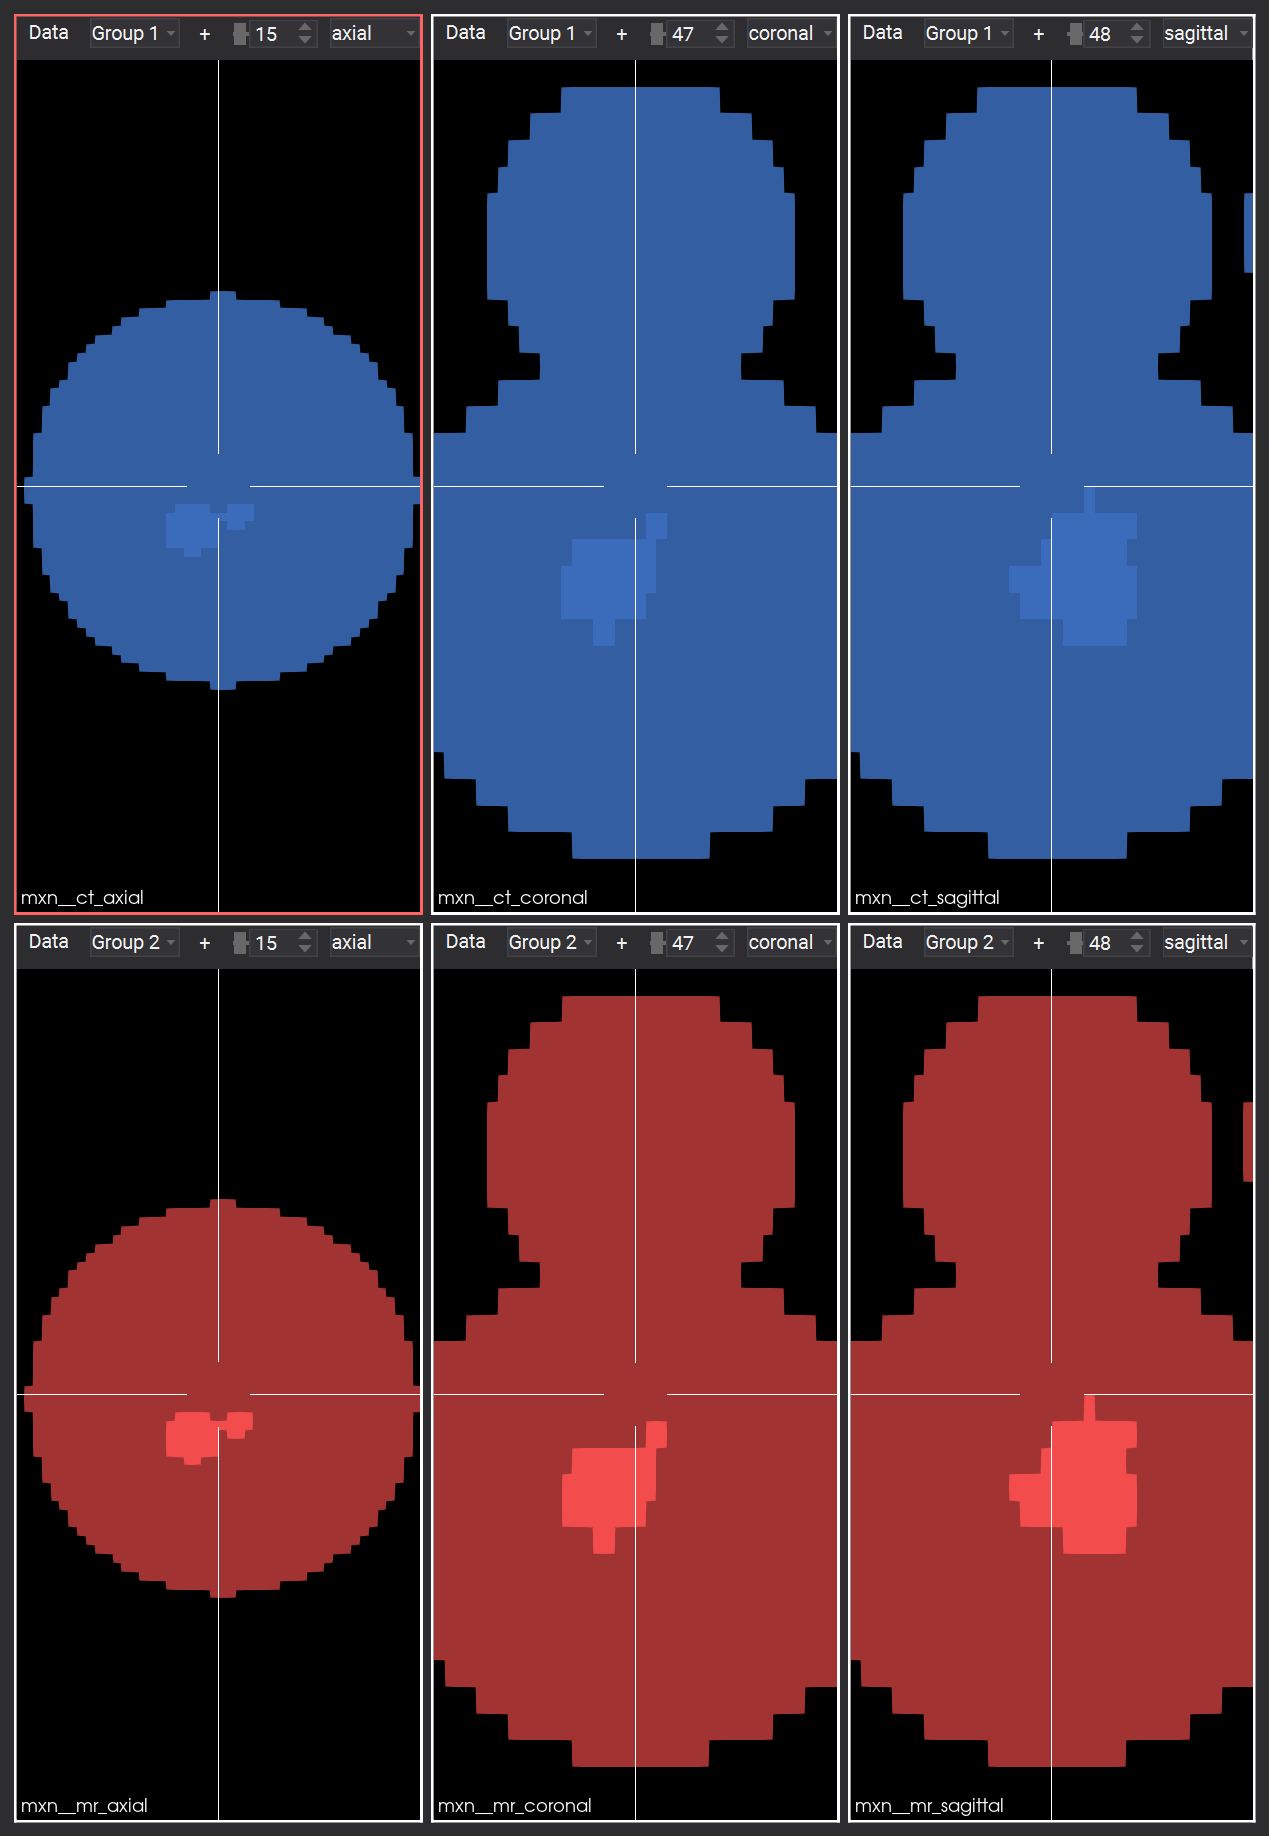

In [9]:
from IPython.display import Image as IPyImage

IPyImage(data=mxn.screenshot(), format="png", width=300)


## JSON-only path (no `mitk` install)

The same flow runs without the optional DSL by trading typed builders for
raw dicts:

- `mxn.get_layout_json()` returns the JSON body unchanged.
- `mxn.set_layout(payload)` accepts a `dict` and PUTs it as-is. The
  server validates the schema and returns 400 `INVALID_REQUEST` on a
  malformed body.

The dict shape mirrors the schema (`mxn-layout-v2.schema.json`) one-to-one
and is byte-stable with what `get_layout_json` returns. Use this path in
environments where a local MITK build is not available; lose only the
client-side validation and the ergonomic builders.


## Recap and clean up

What you exercised:

- `MxNEditor.get_info`, `get_layout`, `set_layout`, `screenshot`
- `MxNRenderWindow.set_node_visible`, `set_node_layer`
- `Workbench.set_position`
- DSL building blocks: `LayoutWindow`, `Split`, `MxNLayoutDocument`,
  selection-linked groups via `selection="<name>"`
- Semantic, plane-encoding cell ids that route end-to-end (URL,
  document, engine) without prefix translation

Notebook 08 reuses these primitives in a cohort-processing script.


In [10]:
mr_node.remove()
ct_node.remove()
print("Removed CT and MR nodes.")


Removed CT and MR nodes.
